# Error Analysis & Error Tracing

This notebook traces model errors across domains, conditions, and models.  
Key questions:

1. **What types of errors do models make?** (magnitude errors, decimal shifts, refusals, hallucinated values, rounding)
2. **Math-only vs No-guide:** When the model can do the arithmetic, but fails the domain-phrased version — why?
3. **Cross-domain consistency:** Same input number, correct in one domain, wrong in another — what drives the difference?
4. **Reasoning vs Non-reasoning:** Do error profiles differ between model types?

This notebook can be used to load in either the full results or only integer values.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (14, 7),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

NON_REASONING_MODELS = ['gpt-4o', 'qwen-coder', 'llama-4', 'gpt-oss-120b']
REASONING_MODELS = ['gpt-5.2', 'deepseek-v3.1', 'claude-haiku-4-5', 'qwen3-235b-thinking']
ALL_MODELS = NON_REASONING_MODELS + REASONING_MODELS

CONDITIONS = {
    'regular':   'results',
    'no_guide':  'results_no_guide',
    'math_only': 'results_math_only',
}

MODEL_DISPLAY = {
    'gpt-4o': 'GPT-4o',
    'qwen-coder': 'Qwen3-Coder',
    'llama-4': 'Llama-4-Maverick',
    'gpt-5.2': 'GPT-5.2 ★',
    'deepseek-v3.1': 'DeepSeek-V3.1 ★',
    'qwen3-235b-thinking': 'Qwen3-235B ★',
    'claude-haiku-4-5': 'Claude-Haiku-4-5 ★',
    'gpt-oss-120b': 'GPT-OSS-120B',
}

MODEL_COLORS = {
    'gpt-4o': '#1f77b4',
    'qwen-coder': '#ff7f0e',
    'llama-4': '#2ca02c',
    'gpt-5.2': '#d62728',
    'deepseek-v3.1': '#9467bd',
    'qwen3-235b-thinking': '#8c564b',
    'claude-haiku-4-5': '#e377c2',
    'gpt-oss-120b': '#7f7f7f',
}

print(f"Models: {ALL_MODELS}")
print(f"Conditions: {list(CONDITIONS.keys())}")

Models: ['gpt-4o', 'qwen-coder', 'llama-4', 'gpt-oss-120b', 'gpt-5.2', 'deepseek-v3.1', 'claude-haiku-4-5', 'qwen3-235b-thinking']
Conditions: ['regular', 'no_guide', 'math_only']


## 1. Load All Results

In [2]:
df = pd.read_csv('/data/jane/convert/math_gender/conversion_test/2_analysis/results.csv', sep='\t')
print(f"loaded {len(df):,} rows")
print(f"columns: {df.columns.tolist()}")
print(f"models: {df['model'].unique()}")
print(f"conditions: {df['condition'].unique()}")
print(f"domains: {df['domain'].unique()}")


/tmp/ipykernel_3101586/372922704.py:1: DtypeWarning: Columns (1,3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/data/jane/convert/math_gender/conversion_test/2_analysis/results.csv', sep='\t')


loaded 3,182,736 rows
columns: ['domain', 'distractor', 'prompt', 'number', 'answer', 'difficulty', 'raw_response', 'model_answer', 'loss', 'reasoning_tokens', 'call_seconds', 'model', 'condition', 'frequency', 'frequency_level', 'is_reasoning', 'display_name', 'is_correct', 'num_decimals', 'num_input_decimals', 'frequency_difficulty']
models: ['claude-haiku-4-5' 'deepseek-v3.1' 'gpt-4o' 'gpt-5.2' 'gpt-oss-120b'
 'llama-4' 'qwen-coder' 'qwen3-235b-thinking']
conditions: ['in_domain_with_guide' 'math_only' 'in_domain_no_guide']
domains: ['bits_bytes' 'clothing_size' 'cooking' 'currency' 'density' 'energy'
 'moles_to_particles' 'speed' 'temperature' 'timezone' 'volume']


In [3]:
# combine all clothing domains into one
df.loc[df['domain'].str.startswith('clothing_sizes_'), 'domain'] = 'clothing_size'


## 2. Error Classification

Classify each wrong answer into an error type based on the relationship between the model's answer and the gold answer.

In [4]:
def classify_error(row):
    """Classify the error type for a single wrong row.
    
    Returns one of:
      'correct'           – loss == 0
      'refusal'           – model refused to answer (N/A, cannot, etc.)
      'rounding'          – loss <= 2 (small precision difference)
      'decimal_shift'     – answer differs by a power of 10
      'magnitude_error'   – answer is >100× or <0.01× the gold
      'wrong_factor'      – off by a recognizable integer factor (2×, 3×, etc.)
      'sign_error'        – correct absolute value, wrong sign
      'moderate_error'    – loss between 2 and 100 (not fitting above)
      'large_error'       – loss > 100
    """
    loss = row['loss']
    if pd.isna(loss) or loss == 0:
        return 'correct'
    
    raw = str(row.get('raw_response', ''))
    if any(kw in raw.lower() for kw in ['n/a', 'cannot', 'i cannot', 'unable to', 'not possible', 'impossible']):
        return 'refusal'
    
    if loss <= 2:
        return 'rounding'
    
    try:
        gold = float(row['answer'])
        model_ans = float(row.get('model_answer', np.nan))
        if pd.isna(model_ans) or gold == 0:
            if loss > 100:
                return 'large_error'
            return 'moderate_error'
        
        ratio = model_ans / gold if gold != 0 else float('inf')
        abs_ratio = abs(ratio)
        
        if abs(gold) > 0 and model_ans < 0 and gold > 0 or model_ans > 0 and gold < 0:
            if abs(abs(model_ans) - abs(gold)) / abs(gold) < 0.05:
                return 'sign_error'
        
        for power in range(-6, 7):
            if power == 0:
                continue
            expected_ratio = 10 ** power
            if 0.9 < abs_ratio / expected_ratio < 1.1:
                return 'decimal_shift'
        
        if abs_ratio > 100 or abs_ratio < 0.01:
            return 'magnitude_error'
        
        for factor in [2, 3, 4, 5, 6, 8, 12, 16, 48]:
            if 0.95 < abs_ratio / factor < 1.05 or 0.95 < abs_ratio * factor < 1.05:
                return 'wrong_factor'
    except (ValueError, TypeError, ZeroDivisionError):
        pass
    
    if loss > 100:
        return 'large_error'
    return 'moderate_error'


df['error_type'] = df.apply(classify_error, axis=1)

print("Error type distribution (all data):")
print(df['error_type'].value_counts().to_string())
print(f"\nTotal correct: {(df['error_type']=='correct').sum():,} / {len(df):,} ({(df['error_type']=='correct').mean()*100:.1f}%)")

Error type distribution (all data):
error_type
correct            2606570
rounding            188310
moderate_error      137095
decimal_shift       115159
magnitude_error      56854
wrong_factor         41570
large_error          29002
refusal               8145
sign_error              31

Total correct: 2,606,570 / 3,182,736 (81.9%)


### 2.1 Error Type Distribution by Model

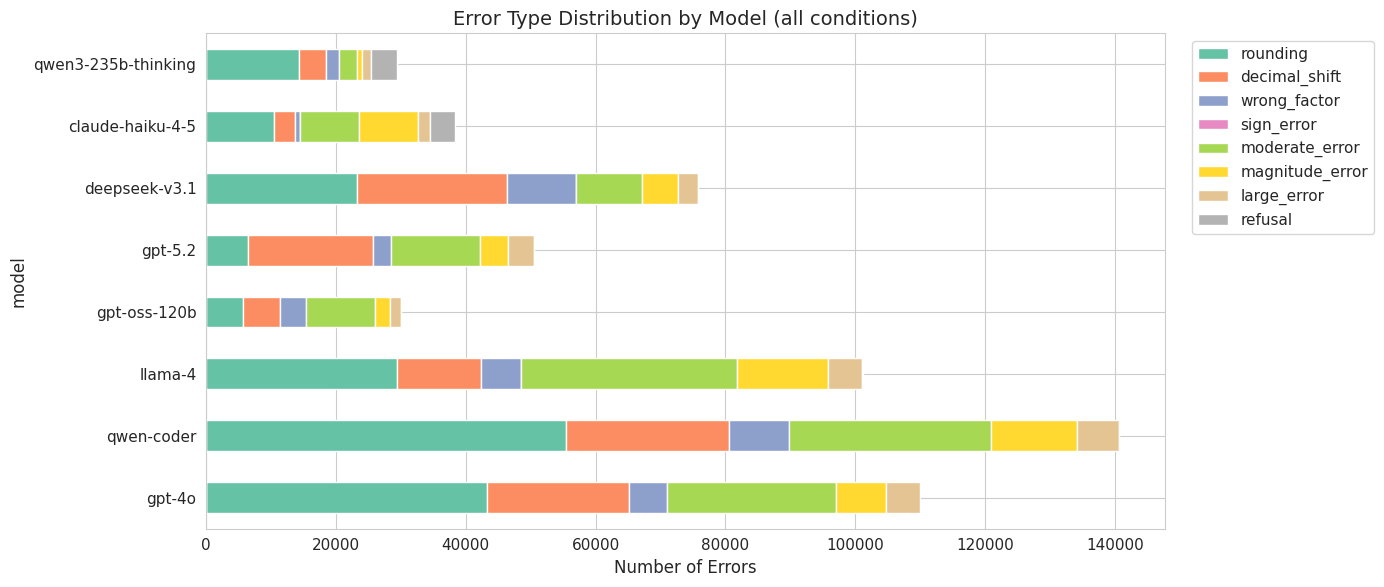


Error counts:
error_type           rounding  decimal_shift  wrong_factor  sign_error  moderate_error  magnitude_error  large_error  refusal
model                                                                                                                        
gpt-4o                  43264          21907          5762           0           26140             7756         5180        0
qwen-coder              55425          25132          9307           0           31105            13152         6560       15
llama-4                 29339          12946          6197           1           33319            14042         5175      189
gpt-oss-120b             5747           5571          4081           0           10692             2228         1720        2
gpt-5.2                  6441          19197          2825           0           13769             4306         4035        1
deepseek-v3.1           23272          23008         10651           1           10224             5474

In [5]:
errors_only = df[df['error_type'] != 'correct'].copy()

ct = pd.crosstab(errors_only['model'], errors_only['error_type'])
ct = ct.reindex(index=[m for m in ALL_MODELS if m in ct.index])
error_order = ['rounding', 'decimal_shift', 'wrong_factor', 'sign_error', 'moderate_error', 'magnitude_error', 'large_error', 'refusal']
ct = ct.reindex(columns=[c for c in error_order if c in ct.columns])

fig, ax = plt.subplots(figsize=(14, 6))
ct.plot(kind='barh', stacked=True, ax=ax, 
        color=sns.color_palette('Set2', len(ct.columns)))
ax.set_xlabel('Number of Errors')
ax.set_title('Error Type Distribution by Model (all conditions)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\nError counts:")
print(ct.to_string())

In [6]:
# Error type breakdown: overall and by model (%)

# Overall distribution
overall = errors_only['error_type'].value_counts()
overall_pct = (overall / overall.sum() * 100).round(1)
overall_df = pd.DataFrame({'count': overall, '%': overall_pct})
overall_df = overall_df.reindex([c for c in error_order if c in overall_df.index])
print("=== Overall Error Type Distribution ===")
print(overall_df.to_string())
print(f"\nTotal errors: {overall.sum():,}")

# Per-model: each row sums to 100%
print("\n\n=== Error Type % by Model (row-normalized) ===")
ct_pct = pd.crosstab(errors_only['model'], errors_only['error_type'], normalize='index') * 100
ct_pct = ct_pct.reindex(index=[m for m in ALL_MODELS if m in ct_pct.index])
ct_pct = ct_pct.reindex(columns=[c for c in error_order if c in ct_pct.columns])
ct_pct['n_errors'] = errors_only.groupby('model').size().reindex(ct_pct.index)
print(ct_pct.round(1).to_string())

# Per-model: share of total errors (column shows what % of ALL errors come from each model)
print("\n\n=== Model Share of Total Errors ===")
model_share = errors_only['model'].value_counts()
model_share_pct = (model_share / model_share.sum() * 100).round(1)
model_share_df = pd.DataFrame({'n_errors': model_share, '% of all errors': model_share_pct})
model_share_df = model_share_df.reindex([m for m in ALL_MODELS if m in model_share_df.index])
print(model_share_df.to_string())

=== Overall Error Type Distribution ===
                  count     %
error_type                   
rounding         188310  32.7
decimal_shift    115159  20.0
wrong_factor      41570   7.2
sign_error           31   0.0
moderate_error   137095  23.8
magnitude_error   56854   9.9
large_error       29002   5.0
refusal            8145   1.4

Total errors: 576,166


=== Error Type % by Model (row-normalized) ===
error_type           rounding  decimal_shift  wrong_factor  sign_error  moderate_error  magnitude_error  large_error  refusal  n_errors
model                                                                                                                                  
gpt-4o                   39.3           19.9           5.2         0.0            23.8              7.1          4.7      0.0    110009
qwen-coder               39.4           17.9           6.6         0.0            22.1              9.3          4.7      0.0    140696
llama-4                  29.0           12.8

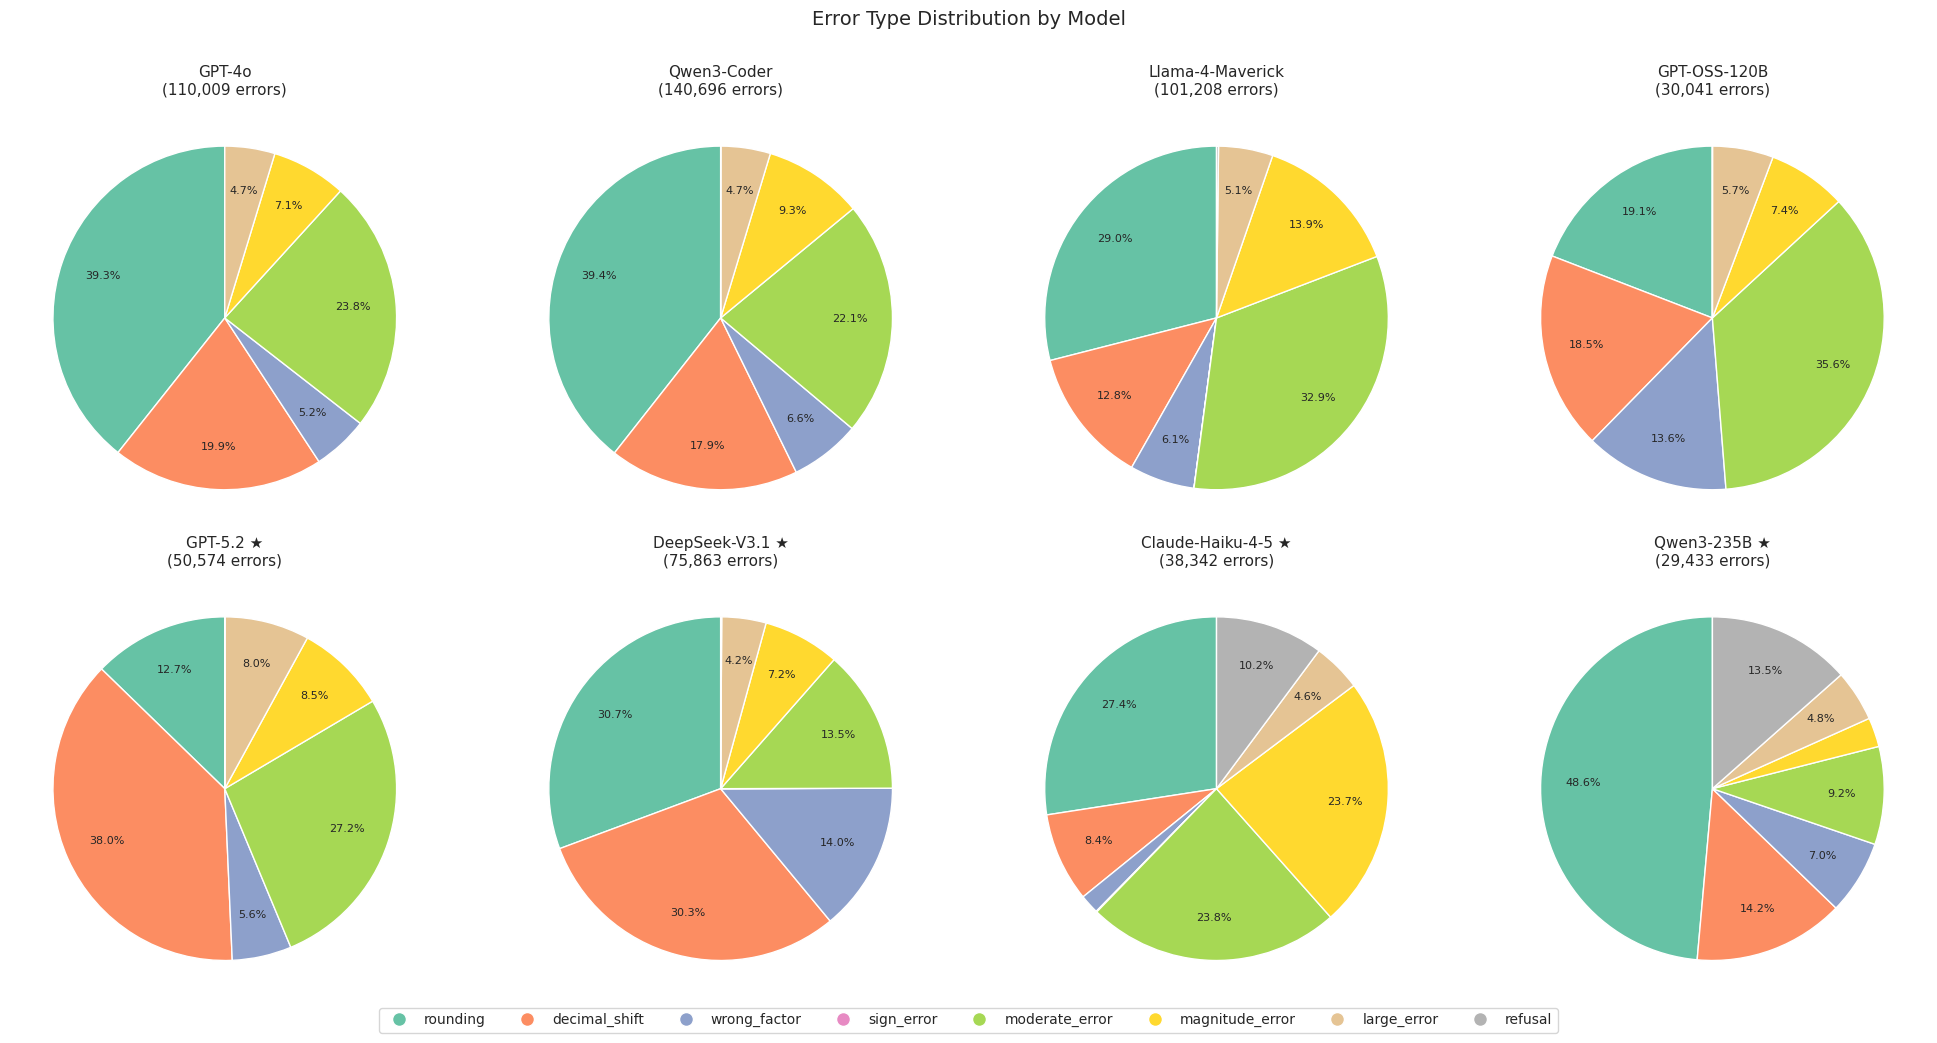

In [7]:
# Pie chart of error type distribution for each model

pie_colors = sns.color_palette('Set2', len(error_order))
color_map = dict(zip(error_order, pie_colors))

models_with_errors = [m for m in ALL_MODELS if m in errors_only['model'].unique()]
n_models = len(models_with_errors)
ncols = 4
nrows = -(-n_models // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = axes.flatten()

for idx, model in enumerate(models_with_errors):
    ax = axes[idx]
    model_errs = errors_only[errors_only['model'] == model]['error_type'].value_counts()
    # Reorder to match error_order, drop zeros
    model_errs = model_errs.reindex([e for e in error_order if e in model_errs.index]).dropna()

    colors = [color_map[e] for e in model_errs.index]
    wedges, texts, autotexts = ax.pie(
        model_errs.values, labels=None, autopct='%1.1f%%',
        colors=colors, startangle=90, pctdistance=0.75,
        textprops={'fontsize': 8}
    )
    # Hide tiny slices' labels
    for at, val in zip(autotexts, model_errs.values):
        if val / model_errs.sum() < 0.03:
            at.set_text('')

    display = MODEL_DISPLAY.get(model, model)
    ax.set_title(f'{display}\n({model_errs.sum():,} errors)', fontsize=11)

# Hide unused axes
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

# Shared legend
legend_handles = [plt.Line2D([0], [0], marker='o', color='w',
                  markerfacecolor=color_map[e], markersize=10, label=e)
                  for e in error_order if e in errors_only['error_type'].values]
fig.legend(handles=legend_handles, loc='lower center', ncol=len(legend_handles),
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Error Type Distribution by Model', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [8]:
# pie chart of error types for each model



### 2.2 Error Type Distribution by Condition

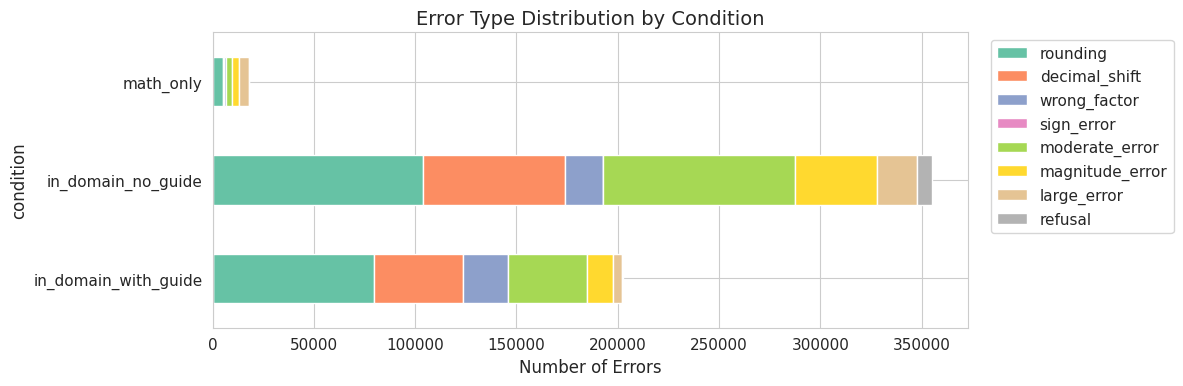


Error counts by condition:
error_type            rounding  decimal_shift  wrong_factor  sign_error  moderate_error  magnitude_error  large_error  refusal
condition                                                                                                                     
in_domain_with_guide     79609          44092         22098           0           39142            12843         4477      537
in_domain_no_guide      103645          70421         18657          30           94719            40634        19450     7602
math_only                 5056            646           815           1            3234             3377         5075        6


In [9]:
ct_cond = pd.crosstab(errors_only['condition'], errors_only['error_type'])
ct_cond = ct_cond.reindex(index=['in_domain_with_guide', 'in_domain_no_guide', 'math_only'])
ct_cond = ct_cond.reindex(columns=[c for c in error_order if c in ct_cond.columns])

fig, ax = plt.subplots(figsize=(12, 4))
ct_cond.plot(kind='barh', stacked=True, ax=ax,
             color=sns.color_palette('Set2', len(ct_cond.columns)))
ax.set_xlabel('Number of Errors')
ax.set_title('Error Type Distribution by Condition')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\nError counts by condition:")
print(ct_cond.to_string())

### 2.3 Error Type Distribution by Domain

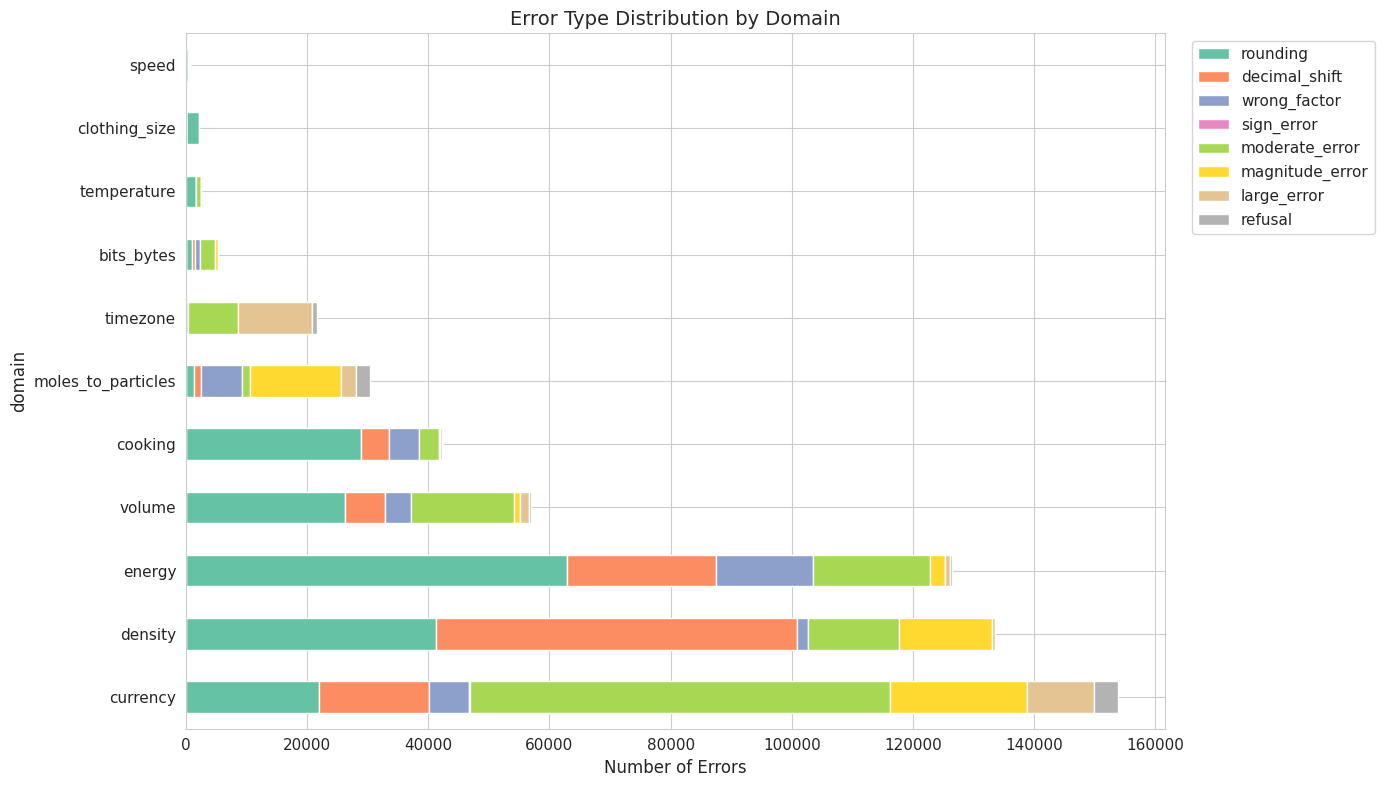

In [10]:
ct_dom = pd.crosstab(errors_only['domain'], errors_only['error_type'])
ct_dom = ct_dom.reindex(columns=[c for c in error_order if c in ct_dom.columns])
ct_dom = ct_dom.loc[ct_dom.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 8))
ct_dom.plot(kind='barh', stacked=True, ax=ax,
            color=sns.color_palette('Set2', len(ct_dom.columns)))
ax.set_xlabel('Number of Errors')
ax.set_title('Error Type Distribution by Domain')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 3. Math-Only vs No-Guide Discrepancy

Find cases where the model solved the math-only (pure arithmetic) version correctly but failed the no-guide (domain-phrased) version — same underlying conversion, same gold answer.

In [11]:
# Separate math_only and no_guide data
mo = df[df['condition'] == 'math_only'].copy()
ng = df[df['condition'] == 'in_domain_no_guide'].copy()

# Exclude clothing (no math_only equivalent)
ng = ng[~ng['domain'].str.contains('clothing')]

# Create join keys: model + domain + number + gold answer
mo['key'] = mo['model'] + '|' + mo['domain'] + '|' + mo['number'].astype(str) + '|' + mo['answer'].astype(str)
ng['key'] = ng['model'] + '|' + ng['domain'] + '|' + ng['number'].astype(str) + '|' + ng['answer'].astype(str)

# Filter: no distractor rows only (for fair comparison)
for d in [mo, ng]:
    mask = d['distractor'].astype(str).isin(['null', 'nan', '', 'None']) | d['distractor'].isna()
    d.drop(d[~mask].index, inplace=True)

mo_correct_keys = set(mo[mo['loss'] == 0]['key'].values)
ng_wrong = ng[ng['loss'] > 0].copy()

# Math correct AND no-guide wrong
ng_wrong['math_correct'] = ng_wrong['key'].isin(mo_correct_keys)
discrepant = ng_wrong[ng_wrong['math_correct']].copy()

print(f"Total no-guide wrong rows: {len(ng_wrong):,}")
print(f"Of which math-only was correct: {len(discrepant):,} ({len(discrepant)/max(len(ng_wrong),1)*100:.1f}%)")
print(f"\nBreakdown by model:")
print(discrepant.groupby('model').size().to_string())

Total no-guide wrong rows: 134,204
Of which math-only was correct: 79,210 (59.0%)

Breakdown by model:
model
claude-haiku-4-5       12640
deepseek-v3.1           4281
gpt-4o                 12631
gpt-5.2                10593
gpt-oss-120b            9838
llama-4                11944
qwen-coder             14719
qwen3-235b-thinking     2564


### 3.1 Discrepancy Rate by Model × Domain

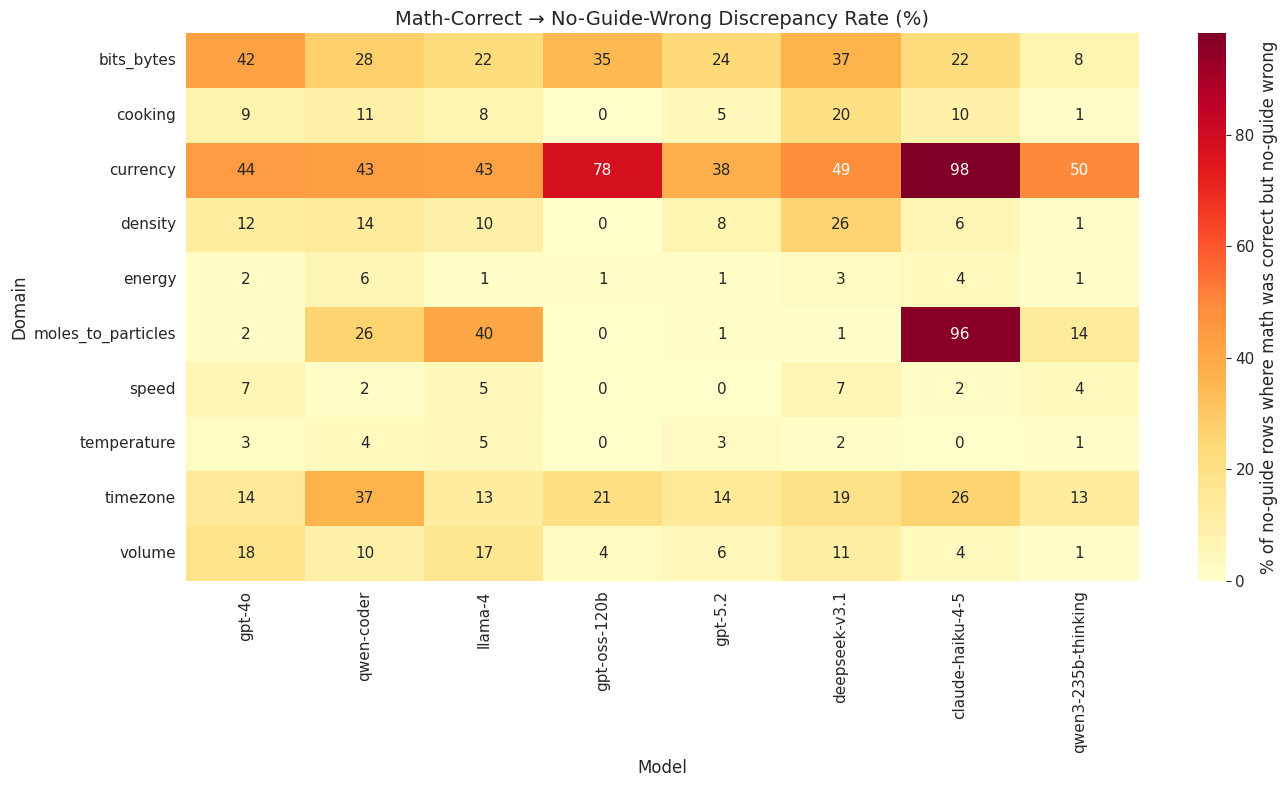

In [12]:
disc_counts = discrepant.groupby(['model', 'domain']).size().reset_index(name='disc_count')
ng_nodist_total = ng.copy()
ng_totals = ng_nodist_total.groupby(['model', 'domain']).size().reset_index(name='total')

disc_rate = disc_counts.merge(ng_totals, on=['model', 'domain'], how='left')
disc_rate['disc_pct'] = (disc_rate['disc_count'] / disc_rate['total'] * 100).round(1)

pivot = disc_rate.pivot(index='domain', columns='model', values='disc_pct').fillna(0)
pivot = pivot.reindex(columns=[m for m in ALL_MODELS if m in pivot.columns])

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': '% of no-guide rows where math was correct but no-guide wrong'})
ax.set_title('Math-Correct → No-Guide-Wrong Discrepancy Rate (%)')
ax.set_ylabel('Domain')
ax.set_xlabel('Model')
plt.tight_layout()
plt.show()

### 3.2 Error Types in Discrepant Cases

When the model got the math right but the domain version wrong — what kind of error did it make?

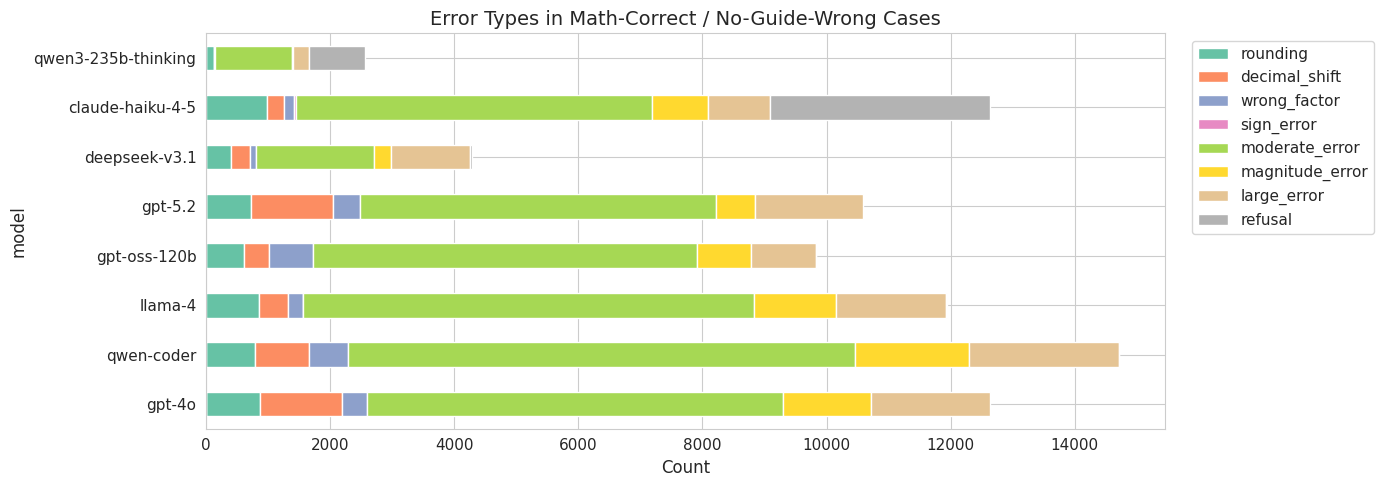

error_type           rounding  decimal_shift  wrong_factor  sign_error  moderate_error  magnitude_error  large_error  refusal
model                                                                                                                        
gpt-4o                    865           1331           404           0            6703             1410         1918        0
qwen-coder                791            862           641           0            8164             1841         2408       12
llama-4                   848            471           249           1            7256             1327         1778       14
gpt-oss-120b              615            396           709           0            6192              865         1060        1
gpt-5.2                   730           1308           449           0            5729              632         1745        0
deepseek-v3.1             399            308            99           0            1892              283         1270  

In [13]:
discrepant['error_type'] = discrepant.apply(classify_error, axis=1)

disc_et = pd.crosstab(discrepant['model'], discrepant['error_type'])
disc_et = disc_et.reindex(index=[m for m in ALL_MODELS if m in disc_et.index])
disc_et = disc_et.reindex(columns=[c for c in error_order if c in disc_et.columns])

fig, ax = plt.subplots(figsize=(14, 5))
disc_et.plot(kind='barh', stacked=True, ax=ax,
             color=sns.color_palette('Set2', len(disc_et.columns)))
ax.set_xlabel('Count')
ax.set_title('Error Types in Math-Correct / No-Guide-Wrong Cases')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(disc_et.to_string())

### 3.3 Example Traces: Math Correct but No-Guide Wrong

Show concrete prompt/response pairs for the most interesting discrepancies.

In [14]:
def show_discrepancy(model_name, domain_name, n=3, min_loss=5):
    """Print side-by-side math-only vs no-guide for a given model and domain."""
    sub = discrepant[(discrepant['model'] == model_name) & (discrepant['domain'] == domain_name)]
    sub = sub[sub['loss'] > min_loss].sort_values('loss', ascending=False).head(n)
    
    if len(sub) == 0:
        print(f"  No discrepancies with loss > {min_loss} for {model_name} / {domain_name}")
        return
    
    for _, row in sub.iterrows():
        key = row['key']
        mo_match = mo[mo['key'] == key]
        if len(mo_match) == 0:
            continue
        mo_row = mo_match.iloc[0]
        
        print(f"{'='*80}")
        print(f"Model: {model_name} | Domain: {domain_name} | Number: {row['number']} | Gold: {row['answer']}")
        print(f"Error type: {row['error_type']} | Loss: {row['loss']:.1f}")
        print(f"{'─'*80}")
        print(f"MATH-ONLY prompt:  {mo_row['prompt']}")
        print(f"MATH-ONLY answer:  {str(mo_row['raw_response'])[:300]}")
        print(f"{'─'*80}")
        print(f"NO-GUIDE prompt:   {row['prompt'][:300]}")
        print(f"NO-GUIDE answer:   {str(row['raw_response'])[:500]}")
        print()


focus_models = ['gpt-4o', 'qwen3-235b-thinking']
focus_domains = ['temperature', 'density', 'volume', 'cooking', 'speed', 'currency', 'timezone']

for m in focus_models:
    print(f"\n{'#'*80}")
    print(f"### {MODEL_DISPLAY.get(m, m)}")
    print(f"{'#'*80}")
    for d in focus_domains:
        sub = discrepant[(discrepant['model'] == m) & (discrepant['domain'] == d)]
        if len(sub) > 0:
            print(f"\n--- {d} ({len(sub)} discrepancies) ---")
            show_discrepancy(m, d, n=2)


################################################################################
### GPT-4o
################################################################################

--- temperature (32 discrepancies) ---
Model: gpt-4o | Domain: temperature | Number: 75000 | Gold: 75273.15
Error type: decimal_shift | Loss: 896.7
────────────────────────────────────────────────────────────────────────────────
MATH-ONLY prompt:  what is 75000+273.15
MATH-ONLY answer:  <answer>75273.15</answer>
────────────────────────────────────────────────────────────────────────────────
NO-GUIDE prompt:   Convert 75000 degrees Celsius to Kelvin. Provide only the numerical value.
NO-GUIDE answer:   <answer>750273.15</answer>

Model: gpt-4o | Domain: temperature | Number: 50000 | Gold: 50273.15
Error type: decimal_shift | Loss: 895.1
────────────────────────────────────────────────────────────────────────────────
MATH-ONLY prompt:  what is 50000+273.15
MATH-ONLY answer:  <answer>50273.15</answer>
──────────────

## 4. Cross-Domain Error Analysis

For a given model and input number, when is the model correct in one domain but wrong in another?  
This reveals whether errors are *input-dependent* or *domain-dependent*.

In [15]:
def find_cross_domain_errors(df_in, model_name, condition='regular', min_loss=5):
    """Find input numbers that are correct in some domains and wrong in others.
    
    Returns a DataFrame with one row per (number, correct_domain, wrong_domain) triplet.
    """
    sub = df_in[(df_in['model'] == model_name) & (df_in['condition'] == condition)].copy()
    
    # Filter to no-distractor
    mask = sub['distractor'].astype(str).isin(['null', 'nan', '', 'None']) | sub['distractor'].isna()
    sub = sub[mask]
    
    # Numeric numbers only (exclude time strings)
    sub = sub[sub['number'].str.match(r'^-?\d+\.?\d*$', na=False)]
    
    correct = sub[sub['loss'] == 0]
    wrong = sub[sub['loss'] > min_loss]
    
    results = []
    for num in wrong['number'].unique():
        c_doms = set(correct[correct['number'] == num]['domain'].unique())
        w_rows = wrong[wrong['number'] == num]
        for _, w_row in w_rows.iterrows():
            w_dom = w_row['domain']
            for c_dom in c_doms:
                if c_dom != w_dom:
                    c_row = correct[(correct['number'] == num) & (correct['domain'] == c_dom)].iloc[0]
                    results.append({
                        'number': num,
                        'correct_domain': c_dom,
                        'correct_gold': c_row['answer'],
                        'wrong_domain': w_dom,
                        'wrong_gold': w_row['answer'],
                        'wrong_response': str(w_row['raw_response'])[:200],
                        'wrong_loss': w_row['loss'],
                        'wrong_error_type': w_row.get('error_type', ''),
                    })
    return pd.DataFrame(results)


print("Computing cross-domain errors for each model (with-guide condition)...")
cross_domain_results = {}
for m in ALL_MODELS:
    cde = find_cross_domain_errors(df, m, condition='regular', min_loss=5)
    if len(cde) > 0:
        cross_domain_results[m] = cde
        print(f"  {m}: {len(cde):,} cross-domain error pairs")
    else:
        print(f"  {m}: no cross-domain errors found")

Computing cross-domain errors for each model (with-guide condition)...
  gpt-4o: no cross-domain errors found
  qwen-coder: no cross-domain errors found
  llama-4: no cross-domain errors found
  gpt-oss-120b: no cross-domain errors found
  gpt-5.2: no cross-domain errors found
  deepseek-v3.1: no cross-domain errors found
  claude-haiku-4-5: no cross-domain errors found
  qwen3-235b-thinking: no cross-domain errors found


### 4.1 Which Domains Fail When Others Succeed?

In [16]:
for model_name in ['gpt-4o', 'qwen3-235b-thinking']:
    if model_name not in cross_domain_results:
        continue
    cde = cross_domain_results[model_name]
    
    # Count how often each domain appears as the "wrong" one vs "correct" one
    wrong_counts = cde['wrong_domain'].value_counts().head(10)
    correct_counts = cde['correct_domain'].value_counts().head(10)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    wrong_counts.plot(kind='barh', ax=ax1, color='#e74c3c')
    ax1.set_title(f'{MODEL_DISPLAY.get(model_name, model_name)}: Most Frequently WRONG Domain\n(when another domain was correct for same input)')
    ax1.set_xlabel('Count')
    
    correct_counts.plot(kind='barh', ax=ax2, color='#2ecc71')
    ax2.set_title(f'{MODEL_DISPLAY.get(model_name, model_name)}: Most Frequently CORRECT Domain\n(when another domain was wrong for same input)')
    ax2.set_xlabel('Count')
    
    plt.tight_layout()
    plt.show()

### 4.2 Cross-Domain Error Heatmap

Row = domain that was wrong, Column = domain that was correct, Cell = how many shared input numbers.

In [17]:
for model_name in ['gpt-4o', 'qwen3-235b-thinking']:
    if model_name not in cross_domain_results:
        continue
    cde = cross_domain_results[model_name]
    
    # Build confusion-style matrix: wrong_domain × correct_domain
    matrix = cde.groupby(['wrong_domain', 'correct_domain']).size().unstack(fill_value=0)
    
    # Only keep domains with meaningful counts
    top_wrong = cde['wrong_domain'].value_counts().head(8).index
    top_correct = cde['correct_domain'].value_counts().head(8).index
    matrix = matrix.reindex(index=top_wrong, columns=top_correct).fillna(0)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(matrix, annot=True, fmt='.0f', cmap='Reds', ax=ax)
    ax.set_title(f'{MODEL_DISPLAY.get(model_name, model_name)}: Cross-Domain Errors (with guide)\n'
                 f'Row = wrong domain, Column = correct domain for same input')
    ax.set_ylabel('Wrong Domain')
    ax.set_xlabel('Correct Domain')
    plt.tight_layout()
    plt.show()

### 4.3 Cross-Domain Example Traces

In [18]:
def show_cross_domain_trace(df_in, model_name, number, condition='regular'):
    """Show how one model handled the same input number across all domains."""
    sub = df_in[(df_in['model'] == model_name) 
                & (df_in['condition'] == condition) 
                & (df_in['number'] == str(number))].copy()
    mask = sub['distractor'].astype(str).isin(['null', 'nan', '', 'None']) | sub['distractor'].isna()
    sub = sub[mask]
    
    if len(sub) == 0:
        print(f"No data for {model_name} / number={number} / {condition}")
        return
    
    print(f"{'='*90}")
    print(f"Model: {model_name} | Input number: {number} | Condition: {condition}")
    print(f"{'='*90}")
    
    # Deduplicate by domain+answer to show one row per conversion
    seen = set()
    for _, row in sub.sort_values('domain').iterrows():
        dkey = f"{row['domain']}|{row['answer']}"
        if dkey in seen:
            continue
        seen.add(dkey)
        
        status = 'CORRECT' if row['loss'] == 0 else f"WRONG (loss={row['loss']:.1f})"
        etype = row.get('error_type', '')
        if etype and etype != 'correct':
            status += f" [{etype}]"
        
        prompt_short = row['prompt'][:120].replace('\n', ' ')
        resp_short = str(row['raw_response'])[:150].replace('\n', ' ')
        
        print(f"\n  {row['domain']:30s}  {status}")
        print(f"    Gold: {row['answer']}")
        print(f"    Prompt:   {prompt_short}...")
        print(f"    Response: {resp_short}...")


# Show a few interesting numbers
print("\n" + "#"*90)
print("GPT-4o with guide — input number = 3")
show_cross_domain_trace(df, 'gpt-4o', '3.0', 'regular')

print("\n" + "#"*90)
print("GPT-4o with guide — input number = 75000")
show_cross_domain_trace(df, 'gpt-4o', '75000.0', 'regular')


##########################################################################################
GPT-4o with guide — input number = 3
No data for gpt-4o / number=3.0 / regular

##########################################################################################
GPT-4o with guide — input number = 75000
No data for gpt-4o / number=75000.0 / regular


## 5. Condition Comparison: With Guide vs No Guide vs Math Only

For each model and domain, compare accuracy rates across the three conditions.


Accuracy (%) by condition — GPT-4o
condition           regular  no_guide  math_only  math−noguide  guide−noguide
domain                                                                       
bits_bytes              NaN       NaN       89.8           NaN            NaN
clothing_size           NaN       NaN        NaN           NaN            NaN
cooking                 NaN       NaN       96.4           NaN            NaN
currency                NaN       NaN       89.8           NaN            NaN
density                 NaN       NaN       90.8           NaN            NaN
energy                  NaN       NaN       94.9           NaN            NaN
moles_to_particles      NaN       NaN      100.0           NaN            NaN
speed                   NaN       NaN       95.8           NaN            NaN
temperature             NaN       NaN       67.3           NaN            NaN
timezone                NaN       NaN       90.6           NaN            NaN
volume                  NaN 

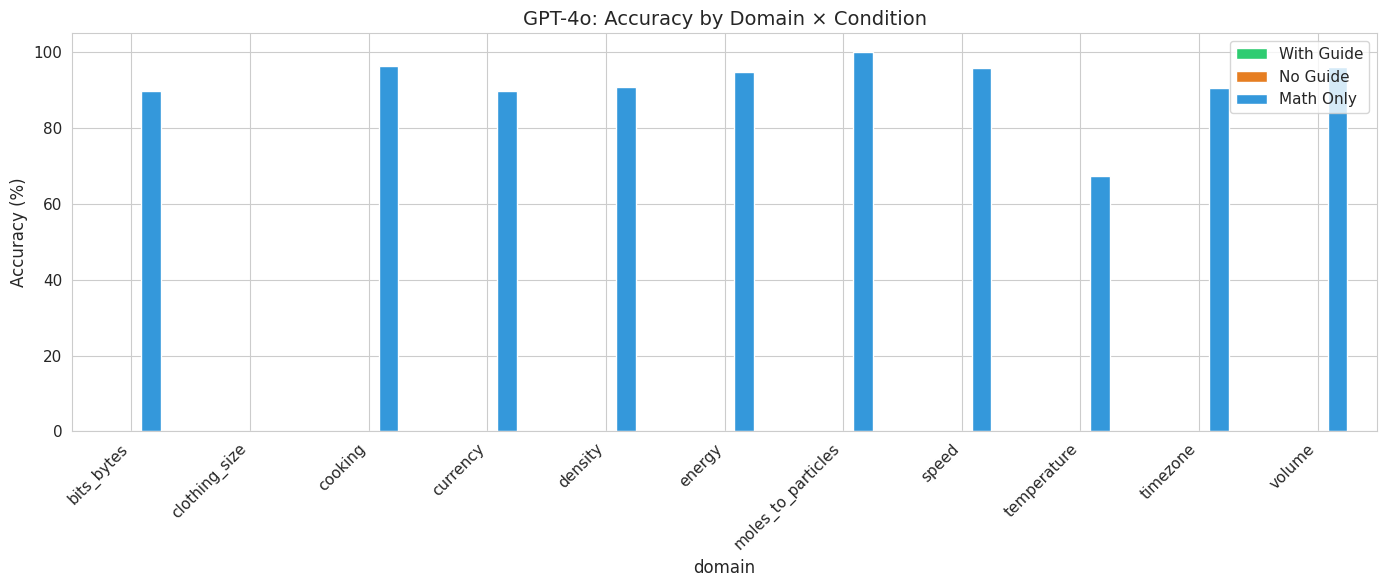


Accuracy (%) by condition — Qwen3-235B ★
condition           regular  no_guide  math_only  math−noguide  guide−noguide
domain                                                                       
bits_bytes              NaN       NaN      100.0           NaN            NaN
clothing_size           NaN       NaN        NaN           NaN            NaN
cooking                 NaN       NaN       99.9           NaN            NaN
currency                NaN       NaN       99.8           NaN            NaN
density                 NaN       NaN       99.9           NaN            NaN
energy                  NaN       NaN      100.0           NaN            NaN
moles_to_particles      NaN       NaN       99.8           NaN            NaN
speed                   NaN       NaN       99.9           NaN            NaN
temperature             NaN       NaN      100.0           NaN            NaN
timezone                NaN       NaN       97.5           NaN            NaN
volume                

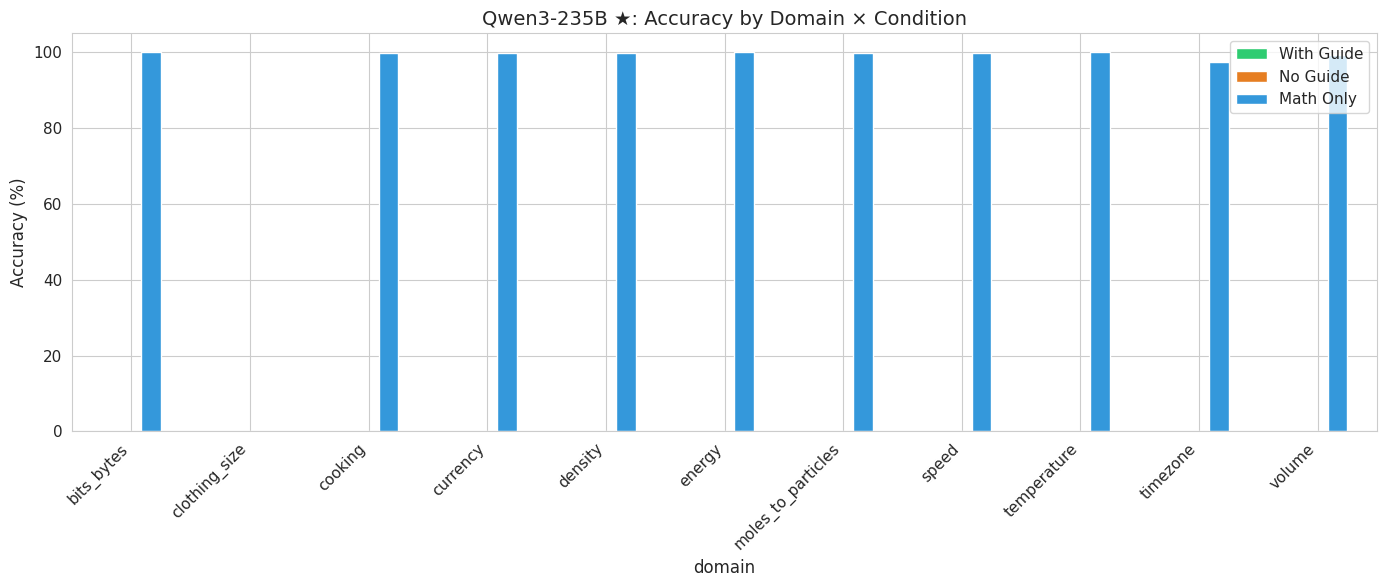

In [19]:
# Compute accuracy per model × domain × condition (no-distractor only)
mask_nodist = df['distractor'].astype(str).isin(['null', 'nan', '', 'None']) | df['distractor'].isna()
df_nodist = df[mask_nodist].copy()

acc = df_nodist.groupby(['model', 'domain', 'condition']).agg(
    total=('loss', 'size'),
    correct=('loss', lambda x: (x == 0).sum()),
).reset_index()
acc['accuracy'] = (acc['correct'] / acc['total'] * 100).round(1)

# Pivot: for each model+domain, show accuracy by condition
for model_name in ['gpt-4o', 'qwen3-235b-thinking']:
    sub = acc[acc['model'] == model_name]
    pivot = sub.pivot(index='domain', columns='condition', values='accuracy')
    pivot = pivot.reindex(columns=['regular', 'no_guide', 'math_only'])
    
    # Add delta columns
    if 'math_only' in pivot.columns and 'no_guide' in pivot.columns:
        pivot['math−noguide'] = (pivot['math_only'] - pivot['no_guide']).round(1)
    if 'regular' in pivot.columns and 'no_guide' in pivot.columns:
        pivot['guide−noguide'] = (pivot['regular'] - pivot['no_guide']).round(1)
    
    print(f"\n{'='*80}")
    print(f"Accuracy (%) by condition — {MODEL_DISPLAY.get(model_name, model_name)}")
    print(f"{'='*80}")
    print(pivot.to_string())
    
    # Plot
    plot_data = pivot[['regular', 'no_guide', 'math_only']].copy()
    fig, ax = plt.subplots(figsize=(14, 6))
    plot_data.plot(kind='bar', ax=ax, color=['#2ecc71', '#e67e22', '#3498db'])
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'{MODEL_DISPLAY.get(model_name, model_name)}: Accuracy by Domain × Condition')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.legend(['With Guide', 'No Guide', 'Math Only'])
    ax.set_ylim(0, 105)
    plt.tight_layout()
    plt.show()

## 6. Loss Distribution Analysis

How large are the errors? Are they mostly small rounding issues or catastrophic failures?

/data/jane/convert/.venv/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


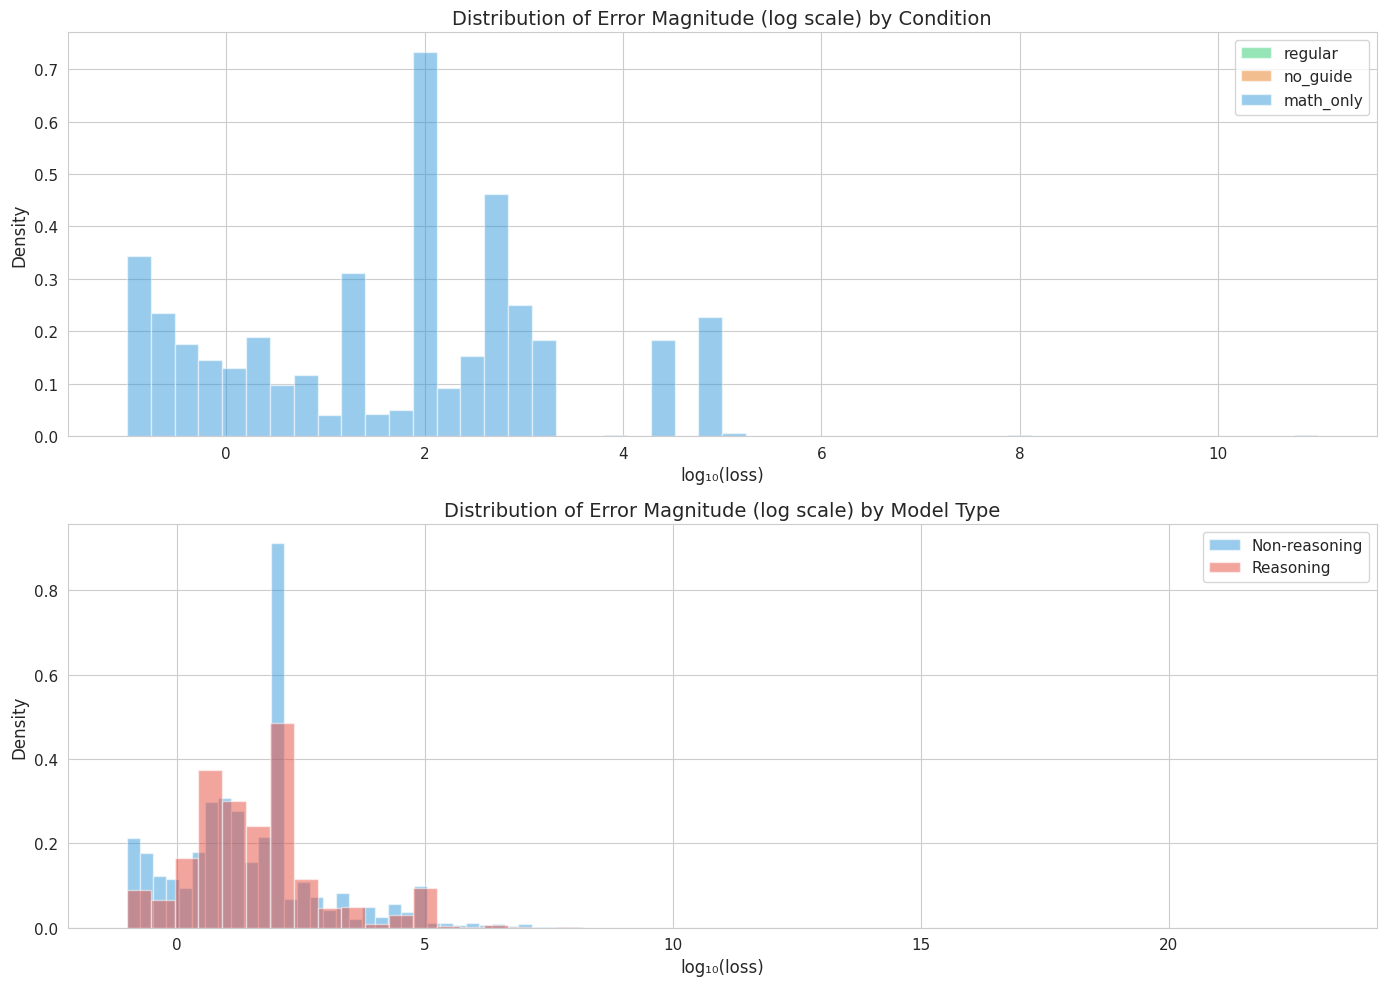


Loss statistics (wrong answers only):
  regular       median=nan  mean=nan  p90=nan  max=nan
  no_guide      median=nan  mean=nan  p90=nan  max=nan
  math_only     median=90.0  mean=27597171.7  p90=29062.3  max=99999999900.0


In [20]:
wrong = df_nodist[df_nodist['loss'] > 0].copy()
wrong['log_loss'] = np.log10(wrong['loss'].clip(lower=1e-6))

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# By condition
for cond, color in zip(['regular', 'no_guide', 'math_only'], ['#2ecc71', '#e67e22', '#3498db']):
    sub = wrong[wrong['condition'] == cond]
    axes[0].hist(sub['log_loss'], bins=50, alpha=0.5, label=cond, color=color, density=True)
axes[0].set_xlabel('log₁₀(loss)')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of Error Magnitude (log scale) by Condition')
axes[0].legend()

# By model type
for is_r, label, color in [(False, 'Non-reasoning', '#3498db'), (True, 'Reasoning', '#e74c3c')]:
    sub = wrong[wrong['is_reasoning'] == is_r]
    axes[1].hist(sub['log_loss'], bins=50, alpha=0.5, label=label, color=color, density=True)
axes[1].set_xlabel('log₁₀(loss)')
axes[1].set_ylabel('Density')
axes[1].set_title('Distribution of Error Magnitude (log scale) by Model Type')
axes[1].legend()

plt.tight_layout()
plt.show()

# Summary statistics
print("\nLoss statistics (wrong answers only):")
for cond in ['regular', 'no_guide', 'math_only']:
    sub = wrong[wrong['condition'] == cond]['loss']
    print(f"  {cond:12s}  median={sub.median():.1f}  mean={sub.mean():.1f}  p90={sub.quantile(0.9):.1f}  max={sub.max():.1f}")

## 7. Interactive Error Lookup

Use these helper functions to trace specific errors.

In [21]:
def lookup_errors(model_name, domain_name=None, condition=None, 
                  min_loss=0, max_results=20, number=None, error_type=None):
    """Search for specific errors in the loaded data.
    
    Args:
        model_name: Model to search
        domain_name: Optional domain filter
        condition: Optional condition filter ('regular', 'no_guide', 'math_only')
        min_loss: Minimum loss threshold
        max_results: Max rows to return
        number: Optional specific input number to search for
        error_type: Optional error type filter
    """
    sub = df[df['model'] == model_name].copy()
    if domain_name:
        sub = sub[sub['domain'] == domain_name]
    if condition:
        sub = sub[sub['condition'] == condition]
    if number is not None:
        sub = sub[sub['number'] == str(number)]
    if error_type:
        sub = sub[sub['error_type'] == error_type]
    
    sub = sub[sub['loss'] > min_loss].sort_values('loss', ascending=False).head(max_results)
    
    if len(sub) == 0:
        print("No matching errors found.")
        return pd.DataFrame()
    
    display_cols = ['domain', 'condition', 'number', 'answer', 'loss', 'error_type']
    if 'model_answer' in sub.columns:
        display_cols.append('model_answer')
    
    print(f"Found {len(sub)} errors for {model_name}:")
    return sub[display_cols]


def trace_number(number, model_name, show_response=True):
    """Trace a specific input number across all conditions and domains for a model.
    
    This shows how the model handled the same number in each (domain, condition) combination.
    """
    sub = df[(df['model'] == model_name) & (df['number'] == str(number))].copy()
    mask = sub['distractor'].astype(str).isin(['null', 'nan', '', 'None']) | sub['distractor'].isna()
    sub = sub[mask]
    
    if len(sub) == 0:
        print(f"No data for model={model_name}, number={number}")
        return
    
    print(f"Tracing number={number} for {model_name} ({len(sub)} rows)")
    print(f"{'Domain':<35s} {'Condition':<12s} {'Gold':<18s} {'Loss':>10s} {'Error Type':<18s} {'Response (start)'}")
    print('─' * 130)
    
    # Deduplicate
    seen = set()
    for _, row in sub.sort_values(['domain', 'condition']).iterrows():
        dkey = f"{row['domain']}|{row['condition']}|{row['answer']}"
        if dkey in seen:
            continue
        seen.add(dkey)
        
        resp_short = str(row['raw_response'])[:60].replace('\n', ' ') if show_response else ''
        loss_str = f"{row['loss']:.1f}" if row['loss'] > 0 else '0'
        etype = row.get('error_type', '')
        if etype == 'correct':
            etype = '✓'
        
        print(f"{row['domain']:<35s} {row['condition']:<12s} {str(row['answer']):<18s} {loss_str:>10s} {etype:<18s} {resp_short}")


def compare_conditions(model_name, domain_name, number):
    """Side-by-side comparison of all three conditions for one specific conversion."""
    for cond in ['regular', 'no_guide', 'math_only']:
        sub = df[(df['model'] == model_name) 
                 & (df['domain'] == domain_name) 
                 & (df['condition'] == cond)
                 & (df['number'] == str(number))].copy()
        mask = sub['distractor'].astype(str).isin(['null', 'nan', '', 'None']) | sub['distractor'].isna()
        sub = sub[mask]
        
        if len(sub) == 0:
            print(f"\n[{cond}] No data")
            continue
        
        row = sub.iloc[0]
        status = '✓ CORRECT' if row['loss'] == 0 else f'✗ WRONG (loss={row["loss"]:.1f})'
        print(f"\n[{cond}] {status}")
        print(f"  Gold: {row['answer']}")
        print(f"  Prompt: {row['prompt'][:300]}")
        print(f"  Response: {str(row['raw_response'])[:500]}")

In [22]:
# Example: Trace number 3.0 for gpt-4o
trace_number('3.0', 'gpt-4o')

No data for model=gpt-4o, number=3.0


In [23]:
# Example: Compare conditions for temperature, number=75000
compare_conditions('gpt-4o', 'temperature', '75000.0')


[regular] No data

[no_guide] No data

[math_only] No data


In [24]:
# Example: Compare conditions for currency, number=1 (qwen3-235b-thinking)
compare_conditions('qwen3-235b-thinking', 'currency', '1.0')


[regular] No data

[no_guide] No data

[math_only] No data


In [25]:
# Example: Find worst decimal_shift errors for gpt-4o
lookup_errors('gpt-4o', error_type='decimal_shift', min_loss=50)

Found 20 errors for gpt-4o:


,domain,condition,number,answer,loss,error_type,model_answer
346743,currency,in_domain_with_guide,0.3847,0.000008,1.000549e+08,decimal_shift,7.9201
2171899,volume,in_domain_no_guide,6000,768000.1589873264,1.039900e+06,decimal_shift,7987200000.0
2171527,volume,in_domain_no_guide,800,102400.0211983102,1.015525e+06,decimal_shift,1040000000.0
2169667,volume,in_domain_no_guide,20,2560.0005299577547,1.009275e+06,decimal_shift,25840000.0
2174596,volume,in_domain_no_guide,273.15,34963.20723789803,1.006764e+06,decimal_shift,352032000.0
2174472,volume,in_domain_no_guide,638.29,81701.13691333676,1.001372e+06,decimal_shift,818214080.0
2193912,volume,in_domain_no_guide,2,8.4535,9.999007e+05,decimal_shift,84535.0575
2196454,volume,in_domain_no_guide,1000,4226.75,9.999007e+05,decimal_shift,42267528.5
346705,currency,in_domain_with_guide,0.0039,0.0,9.968097e+05,decimal_shift,0.0008
2028980,currency,in_domain_no_guide,48.291,0.000994,9.733563e+05,decimal_shift,9.6728


In [26]:
# Example: Find all refusals for qwen3-235b-thinking
lookup_errors('qwen3-235b-thinking', error_type='refusal', min_loss=0)

Found 20 errors for qwen3-235b-thinking:


,domain,condition,number,answer,loss,error_type,model_answer
3101359,energy,in_domain_no_guide,1.0,0.000293,1.228374e+12,refusal,3600000.0
3062226,energy,in_domain_no_guide,0.618,0.147706,2.031068e+11,refusal,300000000.0
1346077,energy,in_domain_with_guide,96.0,0.028135,1.279557e+10,refusal,3600000.0
3102927,energy,in_domain_no_guide,125.0,0.036634,9.826994e+09,refusal,3600000.0
1301388,energy,in_domain_with_guide,5.0,1.195029,4.183000e+05,refusal,5000.0
1301417,energy,in_domain_with_guide,6.0,1.434034,4.183000e+05,refusal,6000.0
1301431,energy,in_domain_with_guide,6.0,1.434034,4.183000e+05,refusal,6000.0
1301393,energy,in_domain_with_guide,5.0,1.195029,4.183000e+05,refusal,5000.0
1301334,energy,in_domain_with_guide,3.0,0.717017,4.183000e+05,refusal,3000.0
1301396,energy,in_domain_with_guide,5.0,1.195029,4.183000e+05,refusal,5000.0


## 8. Aggregate Error Summary

High-level view: error rate and dominant error type per model × domain × condition.

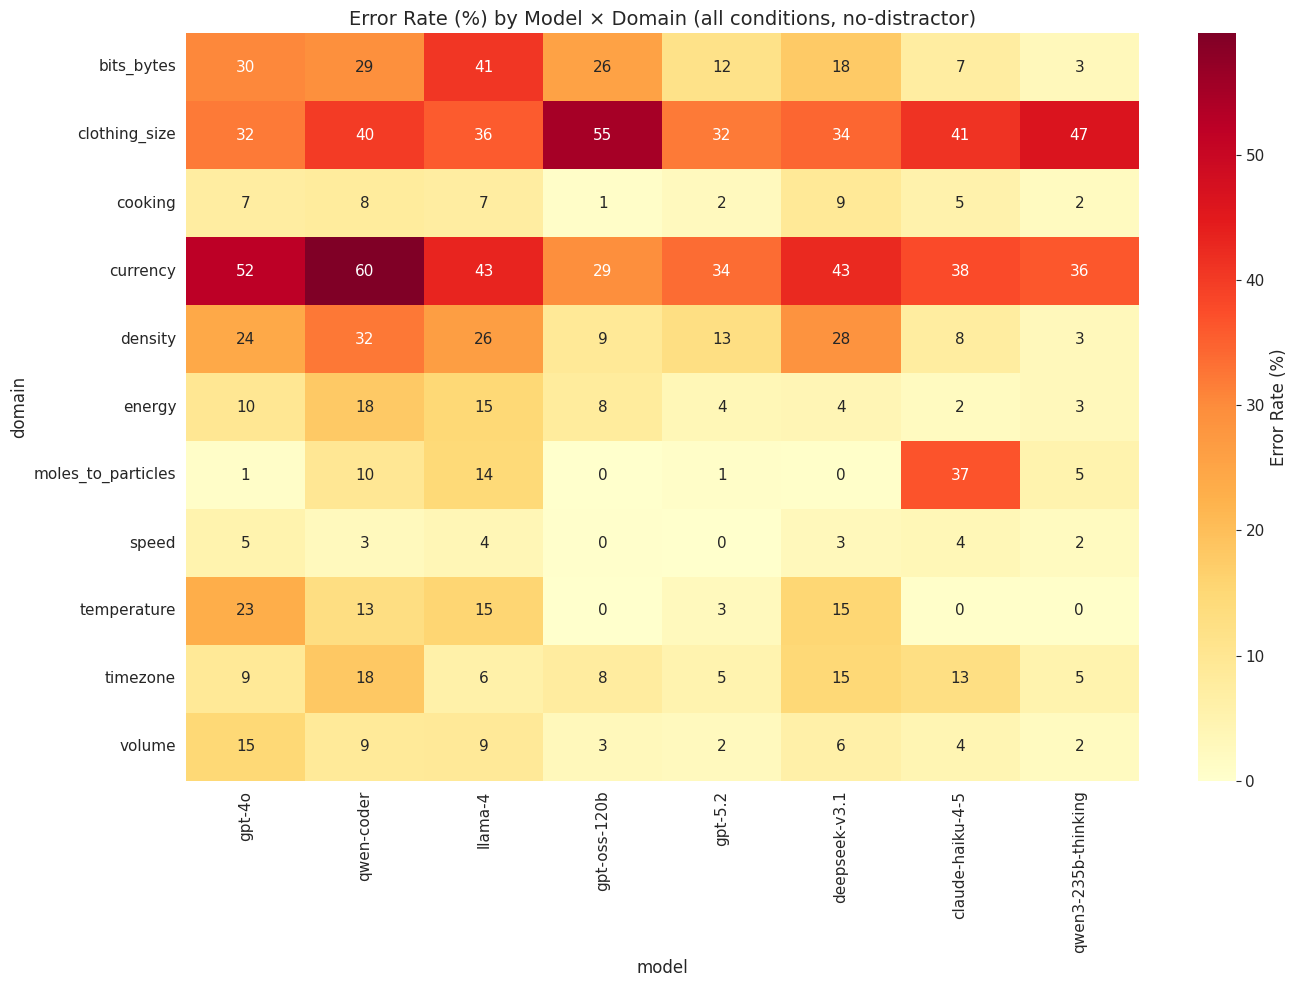

In [27]:
# Error rate heatmap: model × domain (across all conditions)
error_rate = df_nodist.groupby(['model', 'domain']).agg(
    total=('loss', 'size'),
    errors=('loss', lambda x: (x > 0).sum()),
).reset_index()
error_rate['error_pct'] = (error_rate['errors'] / error_rate['total'] * 100).round(1)

pivot_err = error_rate.pivot(index='domain', columns='model', values='error_pct')
pivot_err = pivot_err.reindex(columns=[m for m in ALL_MODELS if m in pivot_err.columns])

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(pivot_err, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Error Rate (%)'})
ax.set_title('Error Rate (%) by Model × Domain (all conditions, no-distractor)')
plt.tight_layout()
plt.show()

In [28]:
# Dominant error type per model × domain
err_only = df_nodist[df_nodist['error_type'] != 'correct']
dominant = err_only.groupby(['model', 'domain'])['error_type'].agg(
    lambda x: x.value_counts().index[0] if len(x) > 0 else 'none'
).unstack(level='model')
dominant = dominant.reindex(columns=[m for m in ALL_MODELS if m in dominant.columns])

print("Dominant error type per model × domain:")
print(dominant.to_string())

Dominant error type per model × domain:
model                       gpt-4o       qwen-coder          llama-4    gpt-oss-120b          gpt-5.2   deepseek-v3.1 claude-haiku-4-5 qwen3-235b-thinking
domain                                                                                                                                                    
bits_bytes          moderate_error   moderate_error   moderate_error  moderate_error   moderate_error  moderate_error   moderate_error      moderate_error
clothing_size             rounding         rounding         rounding        rounding         rounding        rounding         rounding            rounding
cooking                   rounding         rounding         rounding        rounding     wrong_factor        rounding         rounding            rounding
currency            moderate_error   moderate_error   moderate_error  moderate_error   moderate_error  moderate_error   moderate_error      moderate_error
density                   roun

## 9. Distractor Impact on Errors

Do substance distractors (e.g., *"Convert 350 teaspoons of osmium to cups"*) increase errors?

In [29]:
# Domains that have distractors: volume, cooking (and maybe others)
df['has_distractor'] = ~(
    df['distractor'].astype(str).isin(['null', 'nan', '', 'None']) | df['distractor'].isna()
)

domains_with_distractors = df[df['has_distractor']]['domain'].unique()
print(f"Domains with distractor rows: {sorted(domains_with_distractors)}")

# Compare error rates: with vs without distractor
distractor_compare = []
for dom in sorted(domains_with_distractors):
    for m in ALL_MODELS:
        for cond in ['regular', 'no_guide']:
            sub = df[(df['domain'] == dom) & (df['model'] == m) & (df['condition'] == cond)]
            for has_d in [True, False]:
                s = sub[sub['has_distractor'] == has_d]
                if len(s) > 0:
                    distractor_compare.append({
                        'domain': dom, 'model': m, 'condition': cond,
                        'has_distractor': has_d,
                        'n': len(s),
                        'error_rate': (s['loss'] > 0).mean() * 100,
                        'mean_loss': s[s['loss'] > 0]['loss'].mean() if (s['loss'] > 0).any() else 0,
                    })

dc = pd.DataFrame(distractor_compare)
if len(dc) > 0:
    # Pivot for comparison
    for dom in sorted(domains_with_distractors)[:3]:
        sub = dc[(dc['domain'] == dom) & (dc['condition'] == 'no_guide')]
        if len(sub) == 0:
            continue
        pv = sub.pivot(index='model', columns='has_distractor', values='error_rate')
        pv.columns = ['No Distractor', 'With Distractor']
        pv['Delta'] = pv['With Distractor'] - pv['No Distractor']
        pv = pv.reindex(index=[m for m in ALL_MODELS if m in pv.index])
        print(f"\n{dom} (no_guide condition) — Error rate (%):")
        print(pv.round(1).to_string())
    
    # Plot for volume (no_guide)
    sub = dc[(dc['domain'] == 'volume') & (dc['condition'] == 'no_guide')]
    if len(sub) > 0:
        fig, ax = plt.subplots(figsize=(12, 5))
        pv = sub.pivot(index='model', columns='has_distractor', values='error_rate')
        pv.columns = ['No Distractor', 'With Distractor']
        pv = pv.reindex(index=[m for m in ALL_MODELS if m in pv.index])
        pv.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
        ax.set_ylabel('Error Rate (%)')
        ax.set_title('Volume Domain (no guide): Error Rate With vs Without Substance Distractor')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

Domains with distractor rows: ['cooking', 'density', 'energy', 'moles_to_particles', 'volume']


## 10. Reasoning vs Non-Reasoning Error Profiles

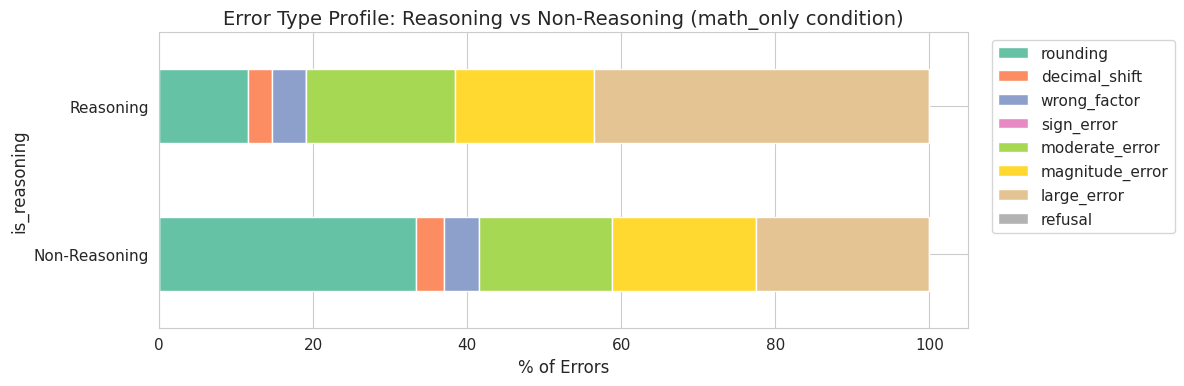

In [30]:
# Compare error type distributions between reasoning and non-reasoning models
err_nodist = df_nodist[df_nodist['error_type'] != 'correct'].copy()

for cond in ['regular', 'no_guide', 'math_only']:
    sub = err_nodist[err_nodist['condition'] == cond]
    if len(sub) == 0:
        continue
    ct = pd.crosstab(sub['is_reasoning'], sub['error_type'], normalize='index') * 100
    ct.index = ct.index.map({True: 'Reasoning', False: 'Non-Reasoning'})
    ct = ct.reindex(columns=[c for c in error_order if c in ct.columns])
    
    fig, ax = plt.subplots(figsize=(12, 4))
    ct.plot(kind='barh', stacked=True, ax=ax,
            color=sns.color_palette('Set2', len(ct.columns)))
    ax.set_xlabel('% of Errors')
    ax.set_title(f'Error Type Profile: Reasoning vs Non-Reasoning ({cond} condition)')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## 11. Detailed No-Guide Error Analysis

The **no_guide** condition is where models must perform conversions using only their parametric knowledge (no conversion guide provided). This section focuses exclusively on that condition to understand where and why models fail without explicit instructions.

In [31]:
ng_all = df[df['condition'] == 'no_guide'].copy()
ng_nodist = ng_all[
    ng_all['distractor'].astype(str).isin(['null', 'nan', '', 'None']) | ng_all['distractor'].isna()
].copy()

print(f"No-guide total rows: {len(ng_all):,}")
print(f"No-guide (no distractor): {len(ng_nodist):,}")
print(f"Models: {sorted(ng_nodist['model'].unique())}")
print(f"Domains: {sorted(ng_nodist['domain'].unique())}")

# --- 11.1 Overall accuracy by model ---
print("\n=== 11.1 No-Guide Accuracy by Model ===")
acc = ng_nodist.groupby('model').agg(
    total=('loss', 'size'),
    correct=('loss', lambda x: (x == 0).sum()),
    wrong=('loss', lambda x: (x > 0).sum()),
    parse_fail=('loss', lambda x: x.isna().sum()),
).reset_index()
acc['accuracy_pct'] = (acc['correct'] / acc['total'] * 100).round(1)
acc['error_pct'] = (acc['wrong'] / acc['total'] * 100).round(1)
acc = acc.sort_values('accuracy_pct', ascending=False)
print(acc.to_string(index=False))

No-guide total rows: 0
No-guide (no distractor): 0
Models: []
Domains: []

=== 11.1 No-Guide Accuracy by Model ===
Empty DataFrame
Columns: [model, total, correct, wrong, parse_fail, accuracy_pct, error_pct]
Index: []


### 11.2 No-Guide Accuracy by Model × Domain

TypeError: Image data of dtype object cannot be converted to float

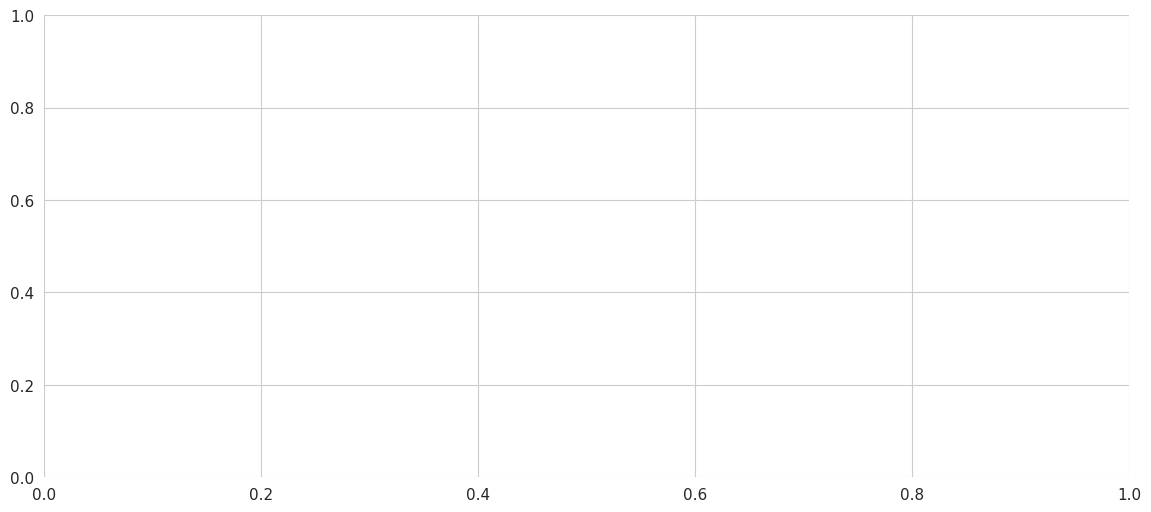

In [32]:
# Accuracy heatmap: model × domain for no_guide
ng_acc = ng_nodist.groupby(['model', 'domain']).apply(
    lambda g: (g['loss'] == 0).sum() / len(g) * 100
).unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(ng_acc, annot=True, fmt='.0f', cmap='RdYlGn', vmin=0, vmax=100,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Accuracy %'})
ax.set_title('No-Guide Accuracy (%) by Model × Domain', fontsize=14)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 11.3 No-Guide Error Type Distribution by Model

In [ ]:
ng_errors = ng_nodist[ng_nodist['error_type'] != 'correct'].copy()
print(f"Total no-guide errors (no distractor): {len(ng_errors):,}\n")

# Crosstab: model × error_type
etype_order = ['rounding', 'decimal_shift', 'wrong_factor', 'sign_error',
               'moderate_error', 'magnitude_error', 'large_error', 'refusal']
ct = pd.crosstab(ng_errors['model'], ng_errors['error_type'])
ct = ct.reindex(columns=[c for c in etype_order if c in ct.columns], fill_value=0)
print(ct.to_string())

# Stacked bar chart
fig, ax = plt.subplots(figsize=(14, 6))
ct.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_title('No-Guide Error Type Distribution by Model', fontsize=14)
ax.set_ylabel('Error Count')
ax.set_xlabel('')
ax.legend(title='Error Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 11.4 No-Guide Error Type Distribution by Domain

In [ ]:
# Crosstab: domain × error_type
ct_dom = pd.crosstab(ng_errors['domain'], ng_errors['error_type'])
ct_dom = ct_dom.reindex(columns=[c for c in etype_order if c in ct_dom.columns], fill_value=0)
ct_dom = ct_dom.loc[ct_dom.sum(axis=1).sort_values(ascending=False).index]
print(ct_dom.to_string())

# Normalized (percentage) heatmap
ct_dom_pct = ct_dom.div(ct_dom.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(ct_dom_pct, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% of errors in domain'})
ax.set_title('No-Guide Error Type Profile by Domain (% of errors)', fontsize=14)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 11.5 No-Guide Loss Severity by Model × Domain

In [ ]:
# Median loss (when wrong) by model × domain
ng_wrong = ng_nodist[ng_nodist['loss'] > 0].copy()
median_loss = ng_wrong.groupby(['model', 'domain'])['loss'].median().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(np.log10(median_loss.clip(lower=0.01)), annot=median_loss.round(1).astype(str).values,
            fmt='', cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'log₁₀(median loss)'})
ax.set_title('No-Guide Median Loss (When Wrong) by Model × Domain', fontsize=14)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Also print the raw numbers
print("\nMedian loss (when wrong):")
print(median_loss.round(2).to_string())

In [ ]:
REASONING = {'gpt-5.2', 'deepseek-v3.1', 'qwen3-235b-thinking', 'qwen3-next-thinking', 'deepseek-r1'}
ng_nodist['model_type'] = ng_nodist['model'].apply(lambda m: 'reasoning' if m in REASONING else 'non-reasoning')

# Error type proportions split by model type
for mt in ['non-reasoning', 'reasoning']:
    sub = ng_nodist[ng_nodist['model_type'] == mt]
    sub_err = sub[sub['error_type'] != 'correct']
    total = len(sub)
    n_err = len(sub_err)
    print(f"\n{'='*50}")
    print(f"{mt.upper()} models — {n_err:,} errors / {total:,} total ({n_err/total*100:.1f}% error rate)")
    print(sub_err['error_type'].value_counts().to_string())

# Side-by-side bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, mt in zip(axes, ['non-reasoning', 'reasoning']):
    sub_err = ng_errors[ng_errors['model'].apply(lambda m: (m in REASONING) == (mt == 'reasoning'))]
    ct_mt = pd.crosstab(sub_err['domain'], sub_err['error_type'])
    ct_mt = ct_mt.reindex(columns=[c for c in etype_order if c in ct_mt.columns], fill_value=0)
    ct_mt = ct_mt.loc[ct_mt.sum(axis=1).sort_values(ascending=False).index]
    ct_mt.plot(kind='barh', stacked=True, ax=ax, colormap='Set2', legend=(mt == 'reasoning'))
    ax.set_title(f'{mt.title()} — No-Guide Errors by Domain', fontsize=12)
    ax.set_xlabel('Error Count')
    if mt == 'reasoning':
        ax.legend(title='Error Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 11.7 No-Guide: Hardest Conversions (Highest Error Rate)

In [ ]:
# Per-model breakdown of worst domains (highest error rate, min 50 samples)
print("=== Top 5 Worst Domains per Model (No-Guide, no distractor) ===\n")
for model in sorted(ng_nodist['model'].unique()):
    sub = ng_nodist[ng_nodist['model'] == model]
    dom_stats = sub.groupby('domain').agg(
        n=('loss', 'size'),
        n_wrong=('loss', lambda x: (x > 0).sum()),
        mean_loss=('loss', lambda x: x[x > 0].mean() if (x > 0).any() else 0),
        dominant_error=('error_type', lambda x: x[x != 'correct'].mode().iloc[0] if (x != 'correct').any() else '-'),
    ).reset_index()
    dom_stats['error_pct'] = (dom_stats['n_wrong'] / dom_stats['n'] * 100).round(1)
    dom_stats = dom_stats[dom_stats['n'] >= 50].sort_values('error_pct', ascending=False)
    print(f"--- {model} ---")
    print(dom_stats[['domain','n','n_wrong','error_pct','mean_loss','dominant_error']].head(5).to_string(index=False))
    print()

In [ ]:
ng_nodist.columns

### 11.8 No-Guide: Difficulty Effect (Easy vs Hard Numbers)

In [ ]:
# Compare error rates for easy vs hard numbers (if difficulty column exists)
if 'difficulty' in ng_nodist.columns:
    diff_stats = ng_nodist.groupby(['model', 'difficulty']).agg(
        n=('loss', 'size'),
        correct=('loss', lambda x: (x == 0).sum()),
    ).reset_index()
    diff_stats['accuracy_pct'] = (diff_stats['correct'] / diff_stats['n'] * 100).round(1)

    pivot = diff_stats.pivot(index='model', columns='difficulty', values='accuracy_pct').fillna(0)
    print("No-Guide Accuracy by Difficulty:\n")
    print(pivot.to_string())

    fig, ax = plt.subplots(figsize=(10, 5))
    pivot.plot(kind='bar', ax=ax, colormap='coolwarm')
    ax.set_title('No-Guide Accuracy: Easy vs Hard Numbers', fontsize=14)
    ax.set_ylabel('Accuracy %')
    ax.set_xlabel('')
    ax.legend(title='Difficulty')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    # Breakdown by domain too
    diff_dom = ng_nodist.groupby(['domain', 'difficulty']).agg(
        n=('loss', 'size'),
        correct=('loss', lambda x: (x == 0).sum()),
    ).reset_index()
    diff_dom['accuracy_pct'] = (diff_dom['correct'] / diff_dom['n'] * 100).round(1)
    pivot_dom = diff_dom.pivot(index='domain', columns='difficulty', values='accuracy_pct').fillna(0)
    print("\nNo-Guide Accuracy by Domain × Difficulty:\n")
    print(pivot_dom.to_string())
else:
    print("No 'difficulty' column found — skipping difficulty analysis.")

### 11.9 No-Guide: Refusal Analysis

Which models refuse to answer, and in which domains?

In [ ]:
refusals = ng_errors[ng_errors['error_type'] == 'refusal']
print(f"Total refusals in no-guide: {len(refusals):,}\n")

if len(refusals) > 0:
    ref_ct = pd.crosstab(refusals['model'], refusals['domain'])
    ref_ct['TOTAL'] = ref_ct.sum(axis=1)
    ref_ct = ref_ct.sort_values('TOTAL', ascending=False)
    print(ref_ct.to_string())

    # Sample refusal responses
    print("\n\n=== Sample Refusal Responses ===")
    for model in refusals['model'].value_counts().head(3).index:
        sub = refusals[refusals['model'] == model].sample(min(3, len(refusals[refusals['model'] == model])), random_state=42)
        for _, r in sub.iterrows():
            raw = str(r.get('raw_response', ''))[:300]
            print(f"\n[{model} | {r['domain']}] number={r['number']}, gold={r['answer']}")
            print(f"  {raw}")
else:
    print("No refusals found.")